In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import mne

In [6]:
# Load dataset
# data = pd.read_csv('data/shivansh_five_class_run_2.csv', header=None)
# print(data.head())

# Load and combine multiple files
files = [
    'data/shivansh_five_class_run_1.csv',
    'data/shivansh_five_class_run_2.csv'
]

data_list = [pd.read_csv(f, header=None) for f in files]
data = pd.concat(data_list, ignore_index=True)
print(f"Combined data shape: {data.shape}")

Combined data shape: (682772, 21)


In [7]:
MI = data[data.iloc[:, 2] == 'mi']
print(f'MI Readings shape: {MI.shape}')
print(MI[:5])

MI Readings shape: (452996, 21)
                0      1   2      3           4           5           6   \
504  11:19:08.0795  still  mi  train  271300.750  245073.562  296443.875   
505  11:19:08.0795  still  mi  train  271332.406  245109.062  296472.031   
506  11:19:08.0795  still  mi  train  271368.062  245140.000  296491.438   
507  11:19:08.0795  still  mi  train  271405.000  245171.203  296514.594   
508  11:19:08.0798  still  mi  train  271441.219  245209.469  296549.906   

             7           8           9   ...          11     12     13     14  \
504  306388.250  254896.531  263546.406  ...  248457.172 -0.025  0.983 -0.236   
505  306416.781  254930.953  263586.000  ...  248498.125 -0.024  0.986 -0.235   
506  306430.438  254963.047  263612.812  ...  248517.969 -0.023  0.984 -0.234   
507  306451.906  254999.984  263643.562  ...  248546.766 -0.024  0.986 -0.233   
508  306491.062  255037.078  263682.750  ...  248591.109 -0.024  0.988 -0.233   

        15     16     17

In [ ]:
readings = MI.iloc[:, 4:12].values
labels = MI.iloc[:, 1].values
split = MI.iloc[:, 3].values
excution_label = MI.iloc[:, 2].values
print(f'Readings shape: {readings.shape}, Labels shape: {labels.shape}')
# left_hand_count = np.sum(labels == 'left_arm')
# print(f'Number of left_hand labels: {left_hand_count}')
print(labels)
la = []
ra = []
rl = []
ll = []
s = []
# assume you already did:
readings = MI.iloc[:, 4:12].values   # shape (n_samples, n_channels)
labels   = MI.iloc[:, 1].values      # shape (n_samples,)

s = []
la = []
ra = []
rl = []
ll = []

n = len(labels)
for i in range(n):
    lbl = labels[i]                      # <- single string label for row i
    row = readings[i, :]                 # <- 1D array for that sample's 8 channels
    if lbl == 'still':
        s.append(row)
    elif lbl == 'left_arm':
        la.append(row)
    elif lbl == 'right_arm':
        ra.append(row)
    elif lbl == 'right_leg':
        rl.append(row)
    elif lbl == 'left_leg':
        ll.append(row)

# convert to numpy arrays if needed
s = np.array(s)
la = np.array(la)
ra = np.array(ra)
rl = np.array(rl)
ll = np.array(ll)

print(f'Still samples: {len(s)}')
print(f'Left arm samples: {len(la)}')
print(f'Right arm samples: {len(ra)}')
print(f'Right leg samples: {len(rl)}')  
print(f'Left leg samples: {len(ll)}')
print(f'Unique labels: {np.unique(labels)}')
print(f'Labels distribution:\n{pd.Series(labels).value_counts()}')
print(readings[:5])

excution_label shape: ['mi' 'mi' 'mi' ... 'mi' 'mi' 'mi']
Readings shape: (452996, 8), Labels shape: (452996,)
['still' 'still' 'still' ... 'right_leg' 'right_leg' 'right_leg']
Still samples: 90556
Left arm samples: 90532
Right arm samples: 90524
Right leg samples: 90584
Left leg samples: 90800
Unique labels: ['left_arm' 'left_leg' 'right_arm' 'right_leg' 'still']
Labels distribution:
left_leg     90800
right_leg    90584
still        90556
left_arm     90532
right_arm    90524
Name: count, dtype: int64
[[271300.75  245073.562 296443.875 306388.25  254896.531 263546.406
  239099.219 248457.172]
 [271332.406 245109.062 296472.031 306416.781 254930.953 263586.
  239136.047 248498.125]
 [271368.062 245140.    296491.438 306430.438 254963.047 263612.812
  239162.328 248517.969]
 [271405.    245171.203 296514.594 306451.906 254999.984 263643.562
  239199.797 248546.766]
 [271441.219 245209.469 296549.906 306491.062 255037.078 263682.75
  239236.188 248591.109]]


In [6]:
# X_train = readings[split == 'train']
# y_train = labels[split == 'train']
# X_test = readings[split == 'test']
# y_test = labels[split == 'test']
# print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

In [7]:

def bandpass_filter(signal, lowcut=4, highcut=40, fs=250, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered


In [8]:


# Verify shape: (n_samples, n_channels)
print("readings.shape:", readings.shape)

fs = 250  # sampling frequency (Hz) - keep this consistent with your data

filtered_readings = np.zeros_like(readings)
for ch_idx in range(readings.shape[1]):  # loop over 8 channels
    raw_signal = readings[:, ch_idx]
    filtered_readings[:, ch_idx] = bandpass_filter(raw_signal, lowcut=4, highcut=40, fs=fs, order=4)

print("filtered_readings shape:", filtered_readings.shape)

readings.shape: (452996, 8)
filtered_readings shape: (452996, 8)


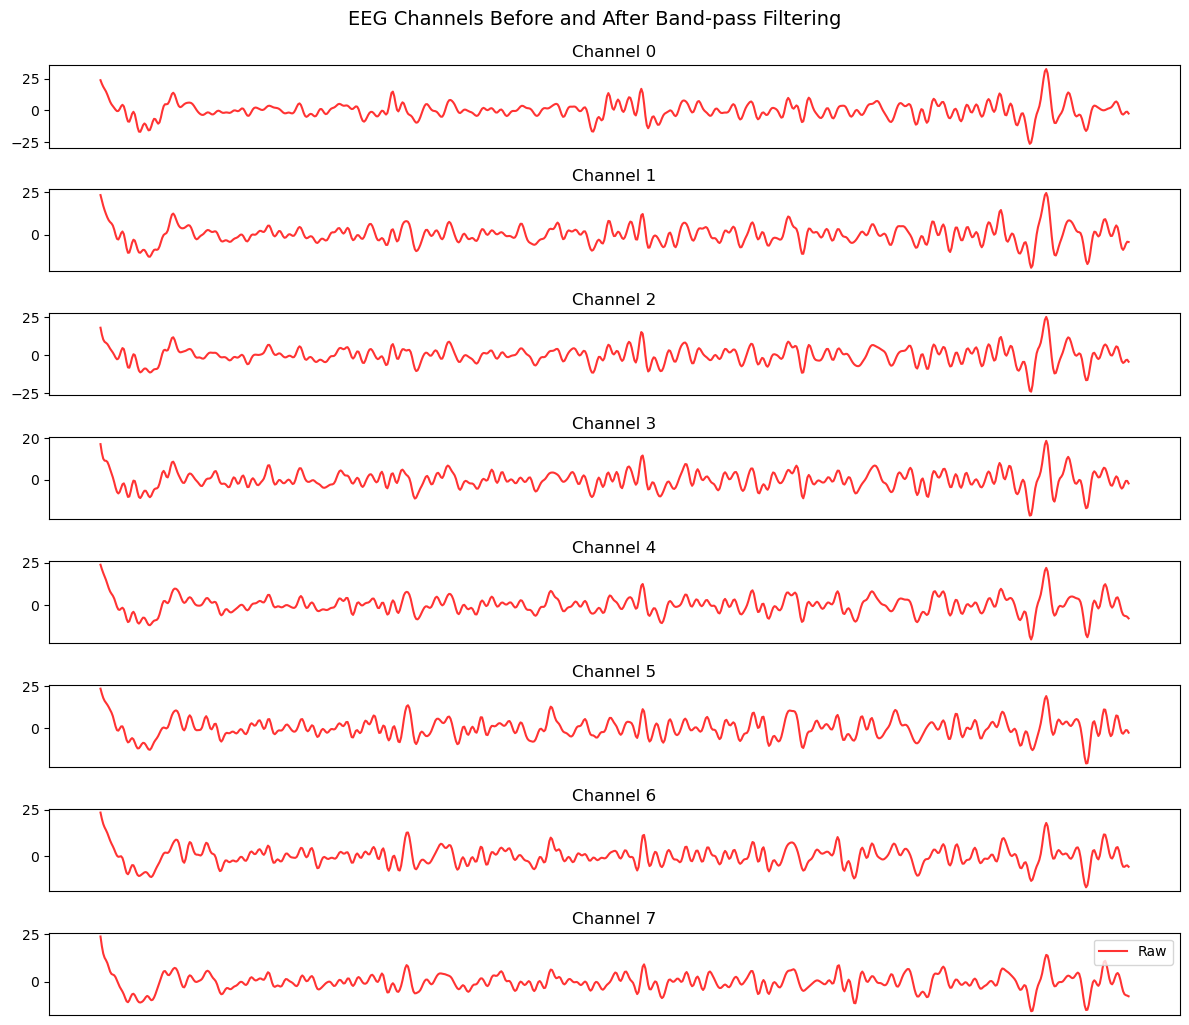

In [9]:
plt.figure(figsize=(12, 10))
for i in range(readings.shape[1]):
    plt.subplot(8, 1, i+1)
    plt.plot(filtered_readings[:750, i], color='red', alpha=0.8, label='Filtered')
    plt.title(f"Channel {i}")
    plt.xticks([])
    plt.tight_layout()

plt.legend(['Raw', 'Filtered'], loc='upper right')
plt.suptitle("EEG Channels Before and After Band-pass Filtering", fontsize=14, y=1.02)
plt.show()



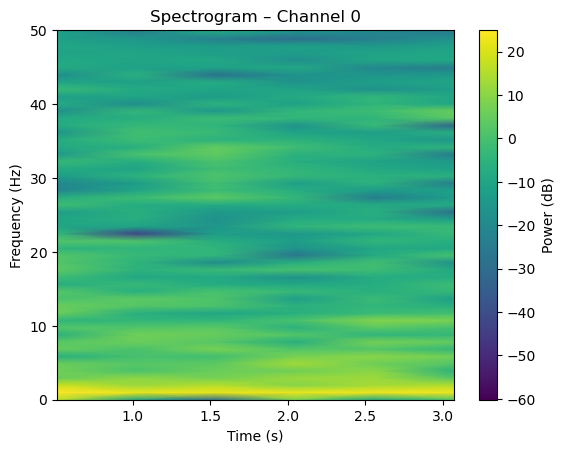

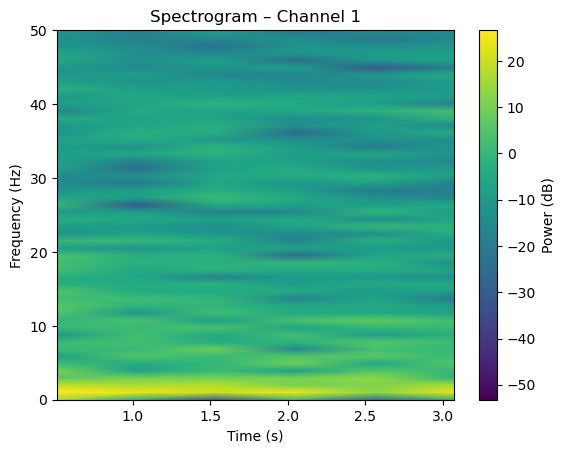

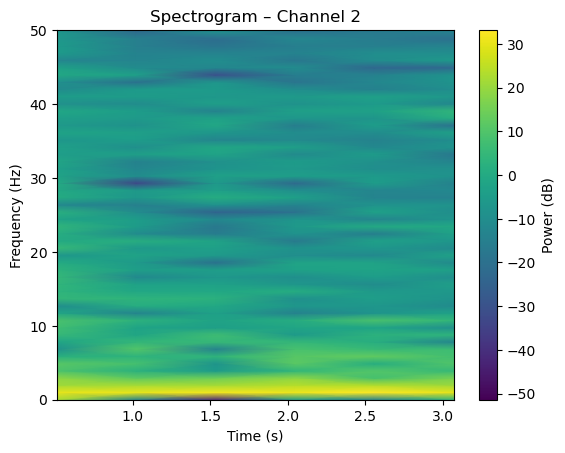

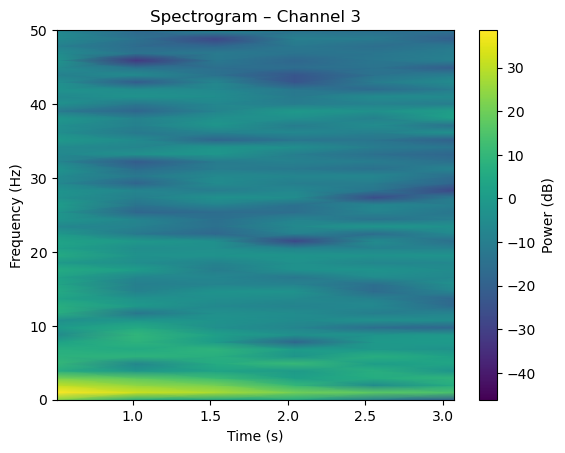

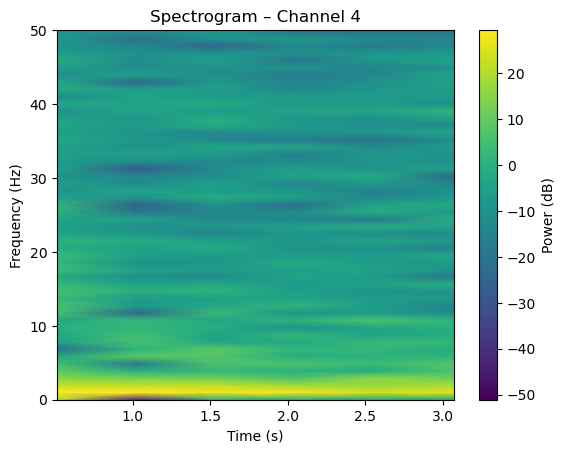

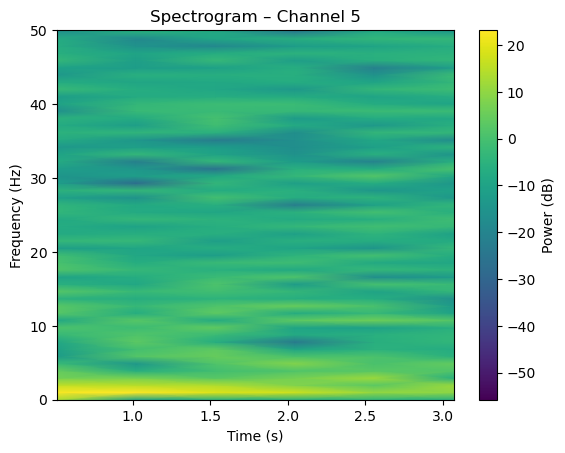

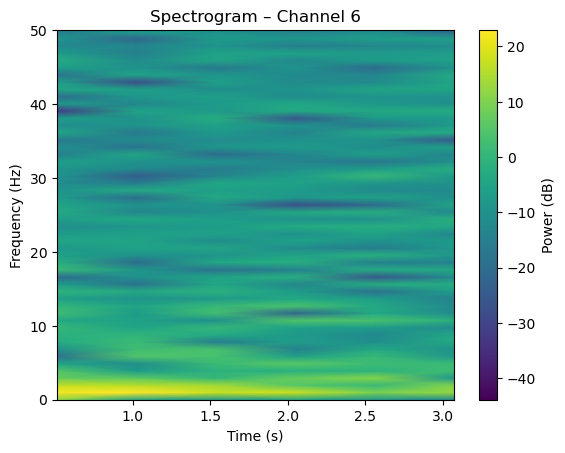

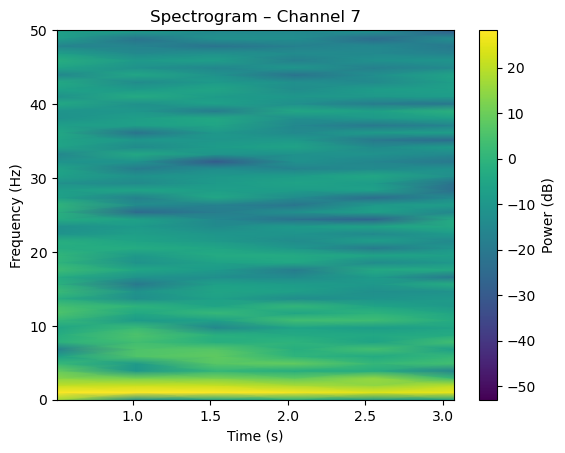

In [10]:
from scipy.signal import spectrogram

ch = 0
for i in range(readings.shape[1]):
    f, t, Sxx = spectrogram(readings[4000:5000, i], fs, nperseg=256, noverlap=128)
    plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud')
    plt.title(f"Spectrogram – Channel {i}")
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.ylim(0, 50)
    plt.colorbar(label='Power (dB)')
    plt.show()




filtered_readings shape: (452996, 8)
Creating RawArray with float64 data, n_channels=8, n_times=452996
    Range : 0 ... 452995 =      0.000 ...  1811.980 secs
Ready.
Fitting ICA...
Fitting ICA to data using 8 channels (please be patient, this may take a while)


C:\Users\Shivansh Sharma\AppData\Local\Temp\ipykernel_23240\2568199852.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_mne)


Selecting by number: 8 components
Fitting ICA took 3.7s.


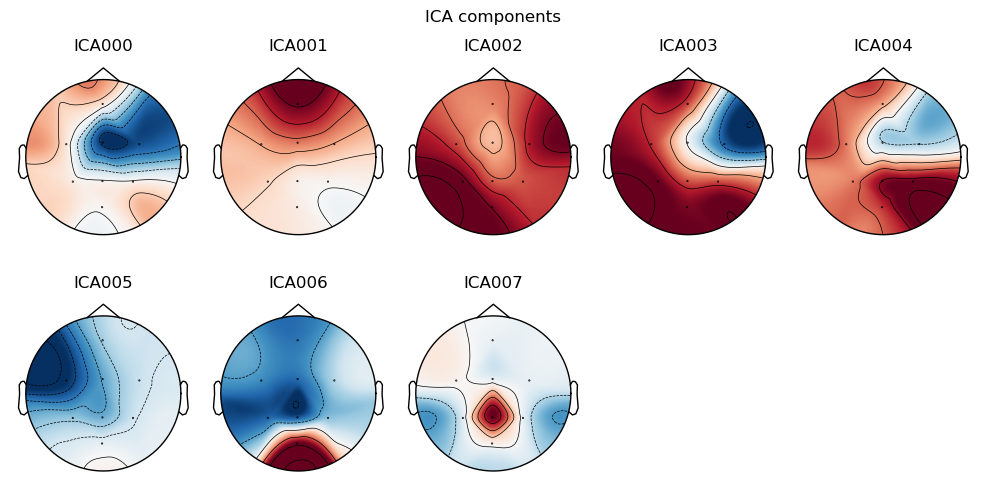

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 1 ICA component
    Projecting back using 8 PCA components
filtered_clean shape: (452996, 8)


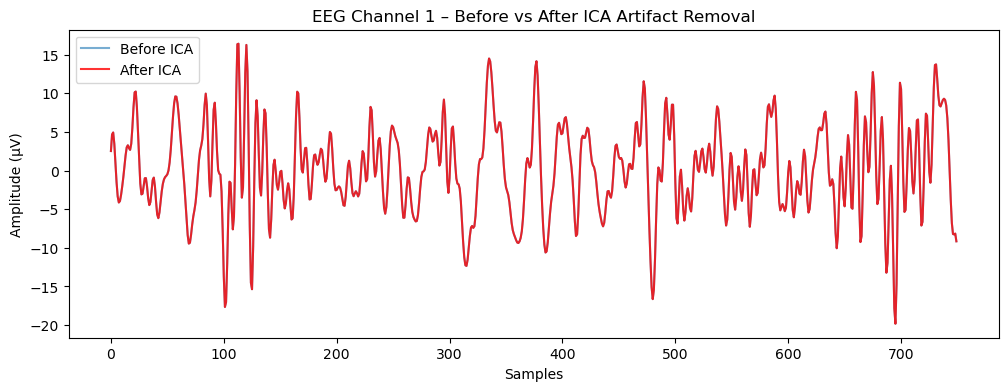

In [11]:
import mne


fs = 250
# Use realistic EEG channel names if possible
ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
ch_types = ['eeg'] * 8
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)

print("filtered_readings shape:", filtered_readings.shape)
raw_mne = mne.io.RawArray(filtered_readings.T, info)

# ✅ Add montage to provide electrode positions
montage = mne.channels.make_standard_montage('standard_1020')
raw_mne.set_montage(montage)
# --- Run ICA ---
ica = mne.preprocessing.ICA(n_components=8, random_state=42, max_iter=500)
print("Fitting ICA...")
ica.fit(raw_mne)

# --- Visualize components safely ---
ica.plot_components()  # now works, shows scalp maps
# OR if you only want time-series of activations:
# ica.plot_sources(raw_mne)

# --- Optionally exclude components ---
ica.exclude = [0]  # change after visual inspection
raw_clean = ica.apply(raw_mne)

filtered_clean = raw_clean.get_data().T
print("filtered_clean shape:", filtered_clean.shape)

# --- Quick comparison ---
plt.figure(figsize=(12, 4))
plt.plot(filtered_readings[4250:5000, 0], label='Before ICA', alpha=0.6)
plt.plot(filtered_clean[4250:5000, 0], label='After ICA', color='red', alpha=0.8)
plt.title('EEG Channel 1 – Before vs After ICA Artifact Removal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (µV)')
plt.legend()
plt.show()

In [12]:

scaler = StandardScaler()
eeg_norm = scaler.fit_transform(filtered_readings)  # shape: (n_samples, 8)

print("eeg_norm shape:", eeg_norm)

eeg_norm shape: [[ 2.78522239  3.49557939  1.35865403 ...  3.90491687  4.66557544
   3.98203154]
 [ 2.4210173   2.96433901  1.30585258 ...  3.39921259  3.97958343
   3.12454707]
 [ 2.12960917  2.49202299  1.22618963 ...  2.97761572  3.42738605
   2.4730071 ]
 ...
 [ 0.49608718  0.65279048  0.63891109 ...  0.81635011 -0.02075131
   1.05966626]
 [ 0.42425219  0.41116769  0.46335991 ...  0.52603837 -0.03545788
   0.64569595]
 [-0.18027903 -0.09310093 -0.1772172  ...  0.07660337 -0.00511849
  -0.12288488]]


In [13]:
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

In [14]:
# -------------------------------
def create_epochs(eeg_array, labels_array, stride, window, amp_thresh=150):
    X, y = [], []
    for start in range(0, len(eeg_array) - window, stride):
        end = start + window
        epoch = eeg_array[start:end, :]
        epoch_labels = labels_array[start:end]
        # majority label in the window
        majority = np.bincount(epoch_labels).argmax()
        purity = np.mean(epoch_labels == majority)
        if purity >= 0.9 and np.max(np.abs(epoch)) < amp_thresh:
            X.append(epoch)
            y.append(majority)
    return np.array(X), np.array(y)

In [15]:
train_idx = np.where(split == 'train')[0]
test_idx  = np.where(split == 'test')[0]

eeg_train, lbl_train = eeg_norm[train_idx], labels_encoded[train_idx]
eeg_test,  lbl_test  = eeg_norm[test_idx],  labels_encoded[test_idx]
print("Train samples:", eeg_train.shape[0])
print("Test samples :", eeg_test.shape[0])

Train samples: 412780
Test samples : 40216


In [16]:
window_sec = 1
window_size = fs * window_sec          # 250 samples per 1 s
train_stride = window_size // 2        # 50 % overlap
test_stride  = window_size             # no overlap
amp_thresh = 150   

X_train, y_train = create_epochs(eeg_train, lbl_train,
                                 stride=train_stride, window=window_size)
X_test, y_test = create_epochs(eeg_test, lbl_test,
                               stride=test_stride, window=window_size)

print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)

Train epochs: (2772, 250, 8) Test epochs: (136, 250, 8)


In [17]:
def normalize_epoch(epoch):
    mean = epoch.mean(axis=0, keepdims=True)
    std = epoch.std(axis=0, keepdims=True) + 1e-8
    return (epoch - mean) / std

X_train = np.array([normalize_epoch(e) for e in X_train])
X_test  = np.array([normalize_epoch(e) for e in X_test])

# --- Reshape for CTNet ---
X_train_ctnet = np.transpose(X_train, (0, 2, 1))  # (N, 8, 250)
X_test_ctnet  = np.transpose(X_test,  (0, 2, 1))


print("CTNet train shape:", X_train_ctnet.shape)
print("CTNet test shape:", X_test_ctnet.shape)

CTNet train shape: (2772, 8, 250)
CTNet test shape: (136, 8, 250)


In [18]:
np.save("X_train_ctnet.npy", X_train_ctnet)
np.save("y_train_ctnet.npy", y_train)
np.save("X_test_ctnet.npy",  X_test_ctnet)
np.save("y_test_ctnet.npy",  y_test)